In [1]:
import pandas as pd, numpy as np, yfinance as yf
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

In [2]:
btc = yf.Ticker("BTC-USD")
data = btc.history('max')

In [3]:
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0


In [10]:
df = pd.DataFrame({
    'ds': data.index,
    'y': data["Close"]
})

In [11]:
df.head()

,ds,y
Date,,
2014-09-17 00:00:00+00:00,2014-09-17 00:00:00+00:00,457.334015
2014-09-18 00:00:00+00:00,2014-09-18 00:00:00+00:00,424.440002
2014-09-19 00:00:00+00:00,2014-09-19 00:00:00+00:00,394.795990
2014-09-20 00:00:00+00:00,2014-09-20 00:00:00+00:00,408.903992
2014-09-21 00:00:00+00:00,2014-09-21 00:00:00+00:00,398.821014


In [13]:
df['ds'] = pd.to_datetime(df['ds']).dt.tz_localize(None)

In [14]:
df.head()

,ds,y
Date,,
2014-09-17 00:00:00+00:00,2014-09-17,457.334015
2014-09-18 00:00:00+00:00,2014-09-18,424.440002
2014-09-19 00:00:00+00:00,2014-09-19,394.795990
2014-09-20 00:00:00+00:00,2014-09-20,408.903992
2014-09-21 00:00:00+00:00,2014-09-21,398.821014


In [16]:
m = Prophet()
m.fit(df)

11:53:56 - cmdstanpy - INFO - Chain [1] start processing
11:53:58 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
future = m.make_future_dataframe(periods=90*1,freq='D')

In [24]:
forecast = m.predict(future)

In [25]:
forecast[['ds','yhat','yhat_lower','yhat_upper',
         'trend','trend_lower','trend_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper
4440,2026-11-14,96613.646843,83979.149905,109340.381727,95258.447223,94391.105717,96268.698322
4441,2026-11-15,96610.329276,84258.496096,108872.440523,95283.751546,94368.274631,96318.435805
4442,2026-11-16,96659.455584,83747.788178,108862.635916,95309.055870,94343.797582,96369.614144
4443,2026-11-17,96585.636128,84300.060260,109196.169319,95334.360193,94325.429029,96429.337963
4444,2026-11-18,96715.239476,83741.582784,109577.135340,95359.664516,94320.033833,96495.728616


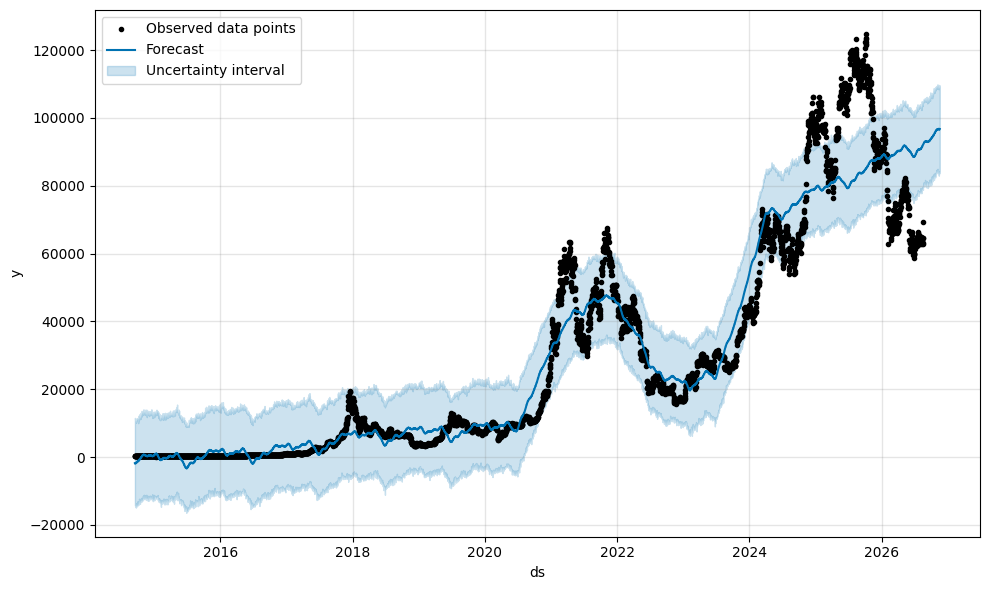

In [26]:
fig1 = m.plot(forecast, include_legend=True)

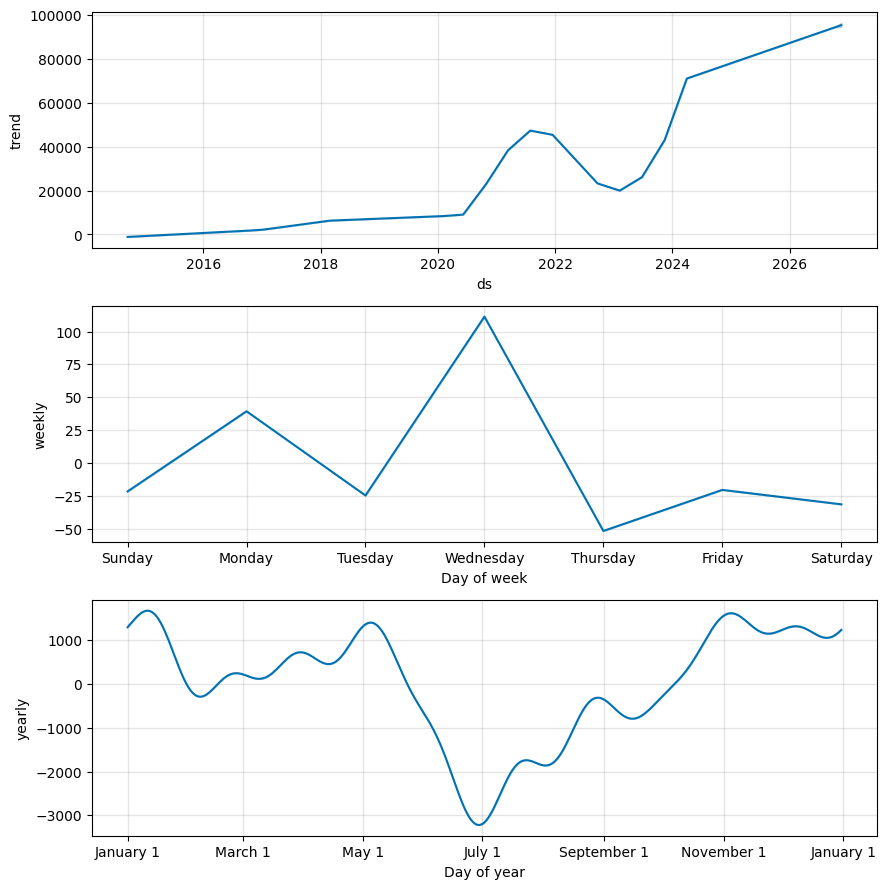

In [27]:
fig2 = m.plot_components(forecast)

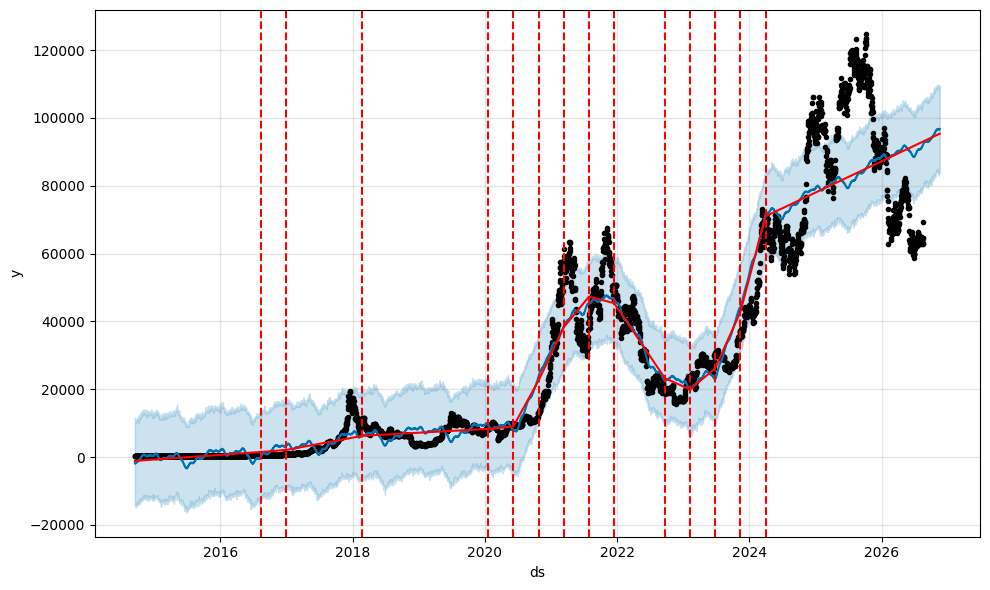

In [28]:
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(),
                             m, forecast)